# N1 · 训一个 mini-SAE 解叠加

> 配套 12.4-L1/L2 · 在玩具 transformer 激活上训稀疏自编码器 (过完备+稀疏), 把叠加的激活分解成稀疏特征。
> 看 SAE 特征比**原始神经元更单义** (纯度对比) —— 解叠加的硬证据。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import sae as S
import tiny_transformer as tt
import numpy as np, torch
torch.manual_seed(0)
Xi,Yi=tt.make_data(2000,seed=0); model=tt.build_model(); tt.train(model,Xi,Yi,epochs=800)
print('玩具 transformer 就绪')

玩具 transformer 就绪


## 1. 收集激活 (跑模型, 取某层 residual) + 训 SAE

激活 (1500, 32) (d_model=32); 概念类别 12 个; SAE 过完备到 36 特征


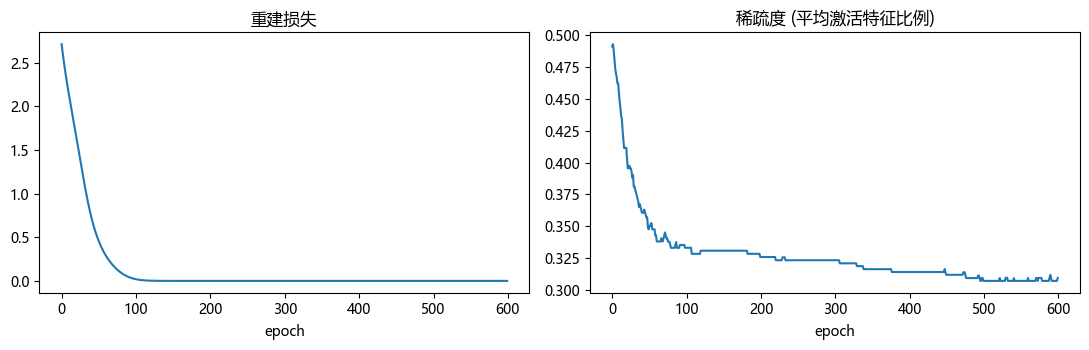

重建 2.711→0.000; 末期稀疏度 0.31 (每次只少数特征激活)


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
acts, labels = S.tiny_mlp_activations(model, tt.make_data(1500, seed=2)[0])
print(f'激活 {acts.shape} (d_model={acts.shape[1]}); 概念类别 {tt.V} 个; SAE 过完备到 {tt.V*3} 特征')
sae = S.build_sae(d_in=acts.shape[1], n_features=tt.V*3)
losses, sparsity = S.train_sae(sae, acts, epochs=600, l1=1e-2)
fig, ax = plt.subplots(1,2,figsize=(11,3.6))
ax[0].plot(losses); ax[0].set_title('重建损失'); ax[0].set_xlabel('epoch')
ax[1].plot(sparsity); ax[1].set_title('稀疏度 (平均激活特征比例)'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()
print(f'重建 {losses[0]:.3f}→{losses[-1]:.3f}; 末期稀疏度 {sparsity[-1]:.2f} (每次只少数特征激活)')

## 2. SAE 特征 vs 原始神经元: 谁更单义

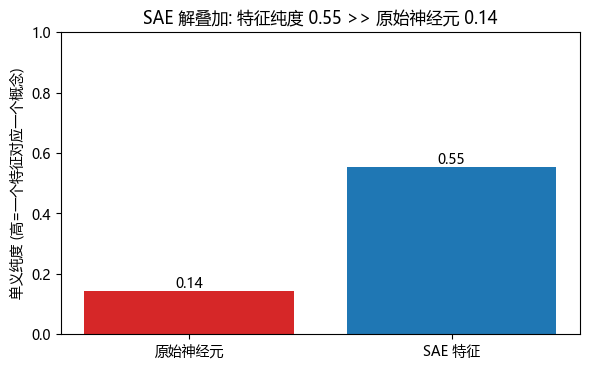

活跃特征 36 个; SAE 纯度 0.55 vs 原始 0.14 (SAE 单义 3.8×)
→ SAE 把叠加的多义激活, 解成更单义的特征 (过完备+稀疏的功劳)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
codes = S.feature_codes(sae, acts)
active, sae_purity = S.monosemanticity(codes, labels)
_, raw_purity = S.monosemanticity(acts - acts.min(), labels)
fig, ax = plt.subplots(figsize=(6,3.8))
ax.bar(['原始神经元','SAE 特征'], [raw_purity, sae_purity], color=['C3','C0'])
for i,v in enumerate([raw_purity, sae_purity]): ax.text(i, v+0.01, f'{v:.2f}', ha='center')
ax.set_ylabel('单义纯度 (高=一个特征对应一个概念)'); ax.set_ylim(0,1)
ax.set_title(f'SAE 解叠加: 特征纯度 {sae_purity:.2f} >> 原始神经元 {raw_purity:.2f}')
plt.tight_layout(); plt.show()
print(f'活跃特征 {len(active)} 个; SAE 纯度 {sae_purity:.2f} vs 原始 {raw_purity:.2f} '
      f'(SAE 单义 {sae_purity/max(raw_purity,1e-6):.1f}×)')
print('→ SAE 把叠加的多义激活, 解成更单义的特征 (过完备+稀疏的功劳)。')

## 3. 反思
你训了一个 mini-SAE 并验证它解叠加。带走:
- **SAE = 过完备 + 稀疏字典**: encode(ReLU,宽) → decode(重建); loss = 重建 + L1 稀疏。
- **解叠加硬证据**: SAE 特征纯度 远高于原始神经元 (定量, 非讲故事)。
- λ (l1) 是旋钮: 稀疏 vs 重建权衡 (你看到的稀疏度)。
> ⚠ 但 (L4): 纯度高 ≠ 特征真实/模型在用; 要因果验证 (干预特征, M12.3)。
下一步 N2: 检视特征是否单义 (最大激活样本) + 真实 gpt2 SAE。